# 3. Feature Engineering
 ---

**Assignment:** *Machine Learning 2026 — NOVA School of Business and Economics*  
**Dataset:** Predict students' dropout and academic success  
**Goal:** Identify high-risk students at the end of their first semester using: Socio-economic background, Enrollment data and 1st semester academic performance

    71907 Lavinia Antonino | 71993 Mª Teresa Silva | 73171 Leonardo Cantu | 72731 Edoardo Sirianni | 71947 Carolina Diogo

 ---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Setup & Data Loading](#2-setup-data-loading)
3. [Drop Zero-Signal Variables](#3-drop-zero-signal-variables)
4. [Academic Performance Features](#4-academic-performance-features)
5. [Financial Features](#5-financial-features)
6. [Demographic Features](#6-demographic-features)
7. [Enrollment & Application Features](#7-enrollment-application-features)
8. [Socioeconomic Features](#8-socioeconomic-features)
9. [Interaction Features](#9-interaction-features)
10. [Final Feature Set & Validation](#10-final-feature-set-validation)
11. [Save Outputs](#11-save-outputs)
12. [Conclusion](#12-conclusion)
---

## 1. Introduction

This notebook translates the findings from the data cleaning and EDA stages into a model-ready feature set. Every decision taken here — what to drop, what to transform, and what to construct — is directly grounded in the quantitative evidence produced in Notebooks 1 and 2. No transformation is applied speculatively.

### EDA Hierarchy of Predictive Signal

The EDA established a clear ranking of variable groups by their discriminative power against the dropout target:

| Priority | Group | Key Evidence |
|---|---|---|
| 1st | **Financial** | Tuition overdue → 94.4% dropout; Debtor → 75.4%; No scholarship → 48.4% |
| 2nd | **Academic (1st sem)** | Approved units → starkest distributional split; Grade → clear separation after handling structural zeros |
| 3rd | **Demographic** | Gender → 26-point gap (30.2% vs 56.2%); Age → older students systematically higher risk |
| 4th | **Enrollment** | Application mode → mature entry at 65.5%; Course → 17–89% range across programmes |
| 5th | **Socioeconomic** | Parental occupation gradient: unskilled 70.9% vs professional 29.2% |
| None | **Macroeconomic** | Zero distributional separation across all three variables — confirmed for removal |

### Engineering Plan

The pipeline follows these steps in order:

1. **Drop** 9 variables with zero or negligible signal (EDA Section 6 Key Findings table)
2. **Academic features** — handle structural zeros in grade; compute approval rate and evaluation intensity ratios; add disengagement flags
3. **Financial features** — build an additive distress score and a high-risk interaction flag
4. **Demographic features** — bin age into ordinal groups aligned with the bivariate analysis; consolidate sparse marital status categories
5. **Enrollment features** — group Application mode into semantic pathway tiers + target encode; ordinal-encode Previous qualification; target-encode Course; clip Application order
6. **Socioeconomic features** — map parental qualifications and occupations to ordinal tiers; build composite SES score
7. **Interaction features** — construct the three interaction terms grounded in EDA Section 5.2
8. **Validate and save** the final feature matrix

> **Leakage note:** Target encoding (Application mode groups and Course) is computed here globally for inspection. In the modelling notebook, both maps must be recomputed inside each cross-validation fold to prevent data leakage.

---
## 2. Setup & Data Loading

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [25]:
df_model = pd.read_csv('../datasets/df_model.csv')

# Work on a copy — original is never modified
df = df_model.copy()

print(f"Modelling set : {df.shape}  |  Target: {df['Target_binary'].value_counts().to_dict()}")
print(f"Class balance : {df['Target_binary'].mean():.1%} Dropout  |  {1 - df['Target_binary'].mean():.1%} Graduate")

Modelling set : (3618, 30)  |  Target: {0: 2201, 1: 1417}
Class balance : 39.2% Dropout  |  60.8% Graduate


In [26]:
# Utility: quick validation — dropout rate per group
def dropout_rate(df, col):
    return (
        df.groupby(col)['Target_binary']
          .agg(dropout_rate='mean', n='count')
          .round(3)
          .sort_values('dropout_rate', ascending=False))

---
## 3. Drop Zero-Signal Variables

The EDA Section 6 Key Findings table identified 9 variables for removal, falling into three justification categories:

| Variable | Reason | Evidence |
|---|---|---|
| `Nacionality` | Near-constant + redundant | 97.9% Portuguese; r=0.92 with `International` |
| `International` | Near-constant + redundant | 97.6% domestic; only 86 students left |
| `Educational special needs` | Near-constant | 98.9% = 0; 40 positive cases only |
| `Displaced` | No signal | No marginal signal in bivariate vs target |
| `Curricular units 1st sem (credited)` | Zero-inflated, no signal | 86.9% zeros; no bivariate separation |
| `Curricular units 1st sem (without evaluations)` | Near-constant | 93.8% zeros; no signal |
| `Unemployment rate` | No signal | Identical distribution across Graduate/Dropout |
| `Inflation rate` | No signal | Identical distribution across Graduate/Dropout |
| `GDP` | No signal | Identical distribution across Graduate/Dropout |

In [27]:
COLS_TO_DROP = [
    # Near-constant / redundant pair
    'Nacionality',
    'International',
    # Near-constant, no discriminative power
    'Educational special needs',
    'Displaced',
    # Zero-inflated academic variables — no target separation
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (without evaluations)',
    # Macroeconomic — removed on signal grounds, not collinearity
    'Unemployment rate',
    'Inflation rate',
    'GDP',
]

df = df.drop(columns=COLS_TO_DROP)

print(f"Variables dropped : {len(COLS_TO_DROP)}")
print(f"Shape after drop  : {df.shape}")
print(f"\nRemaining raw columns ({df.shape[1]}):\n{df.columns.tolist()}")

Variables dropped : 9
Shape after drop  : (3618, 21)

Remaining raw columns (21):
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Target', 'Target_binary']


Nine variables are removed across three categories: two near-constant redundant pairs 
(Nationality and International, r=0.92), two no-signal variables (Educational special needs 
with only 40 positive cases, and Displaced with no bivariate separation), two zero-inflated 
academic variables (credited units at 86.9% zeros and without evaluations at 93.8% zeros with 
no target separation), and three macroeconomic variables removed on signal grounds — their 
distributions across graduates and dropouts were indistinguishable in the EDA. The remaining 
21 columns proceed to feature construction.

---
## 4. Academic Performance Features

The 1st semester academic group is the second-strongest predictor group. Four variables remain after Step 1. The EDA found:

- **`Approved`** is the single strongest academic separator — dropouts cluster near zero; graduates concentrate around 5–6 units
- **`Grade`** shows clear separation but has a structural zero problem: `grade = 0` whenever `approved = 0`. These are not true grades of zero — they are absences of a grade. The raw variable is kept but the subgroup is isolated with a flag
- **`Enrolled` ↔ `Approved`** correlate at 0.77 (EDA multivariate) — an approval rate ratio compresses this into one more informative feature
- **`Evaluations`** carries a zero spike (319 students with no exams — a complete disengagement signal) and a high-end signal (many evaluations relative to enrolled = resit behaviour)

Four engineered features are created: `approval_rate`, `eval_intensity`, `zero_approved_flag`, and `zero_eval_flag`.

In [28]:
def build_academic_features(df):
    df = df.copy()
    enrolled    = df['Curricular units 1st sem (enrolled)']
    approved    = df['Curricular units 1st sem (approved)']
    evaluations = df['Curricular units 1st sem (evaluations)']

    # Approval rate: approved / enrolled
    # Compresses the 0.77 enrolled-approved correlation into one normalised feature
    # Students with 0 enrolled receive 0 (no opportunity to pass anything)
    df['approval_rate'] = np.where(enrolled > 0, approved / enrolled, 0.0)

    # Evaluation intensity: evaluations / enrolled
    # > 1.0 signals resit behaviour (struggling); 0.0 signals complete disengagement
    df['eval_intensity'] = np.where(enrolled > 0, evaluations / enrolled, 0.0)

    # Zero-approved flag: passed nothing in semester 1
    # Also cleanly isolates the structural zero cluster in grade
    # (grade = 0 iff approved = 0 — confirmed in cleaning notebook)
    df['zero_approved_flag'] = (approved == 0).astype(int)

    # Zero-evaluation flag: sat no exams whatsoever
    # Captures complete early disengagement — students who likely left during the semester
    df['zero_eval_flag'] = (evaluations == 0).astype(int)

    return df

df = build_academic_features(df)

print("Academic features created:")
print(f"  approval_rate      range [{df['approval_rate'].min():.2f}, {df['approval_rate'].max():.2f}]  mean {df['approval_rate'].mean():.3f}")
print(f"  eval_intensity     range [{df['eval_intensity'].min():.2f}, {df['eval_intensity'].max():.2f}]  mean {df['eval_intensity'].mean():.3f}")
print(f"  zero_approved_flag  {df['zero_approved_flag'].sum()} students ({df['zero_approved_flag'].mean():.1%})")
print(f"  zero_eval_flag      {df['zero_eval_flag'].sum()} students ({df['zero_eval_flag'].mean():.1%})")

Academic features created:
  approval_rate      range [0.00, 1.00]  mean 0.700
  eval_intensity     range [0.00, 3.50]  mean 1.236
  zero_approved_flag  644 students (17.8%)
  zero_eval_flag      319 students (8.8%)


In [29]:
print("Dropout rate — zero_approved_flag (0=passed something, 1=passed nothing):")
print(dropout_rate(df, 'zero_approved_flag'))
print()
print("Dropout rate — zero_eval_flag (0=sat some exams, 1=sat no exams):")
print(dropout_rate(df, 'zero_eval_flag'))

Dropout rate — zero_approved_flag (0=passed something, 1=passed nothing):
                    dropout_rate     n
zero_approved_flag                    
1                         0.8800   644
0                         0.2860  2974

Dropout rate — zero_eval_flag (0=sat some exams, 1=sat no exams):
                dropout_rate     n
zero_eval_flag                    
1                     0.7650   319
0                     0.3560  3299


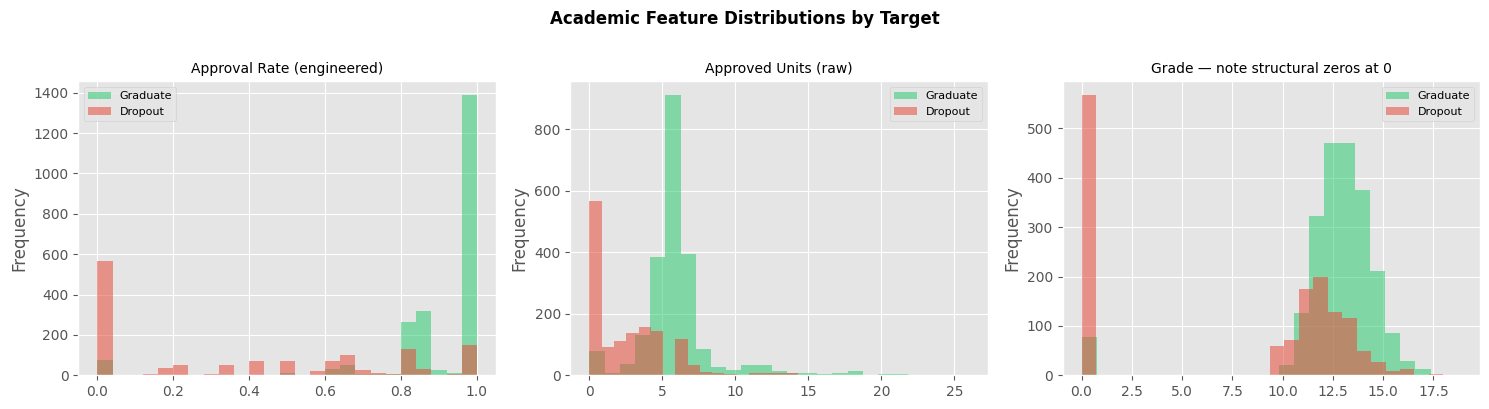

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = {0: '#2ecc71', 1: '#e74c3c'}
labels  = {0: 'Graduate', 1: 'Dropout'}

for ax, col, title in zip(
    axes,
    ['approval_rate', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)'],
    ['Approval Rate (engineered)', 'Approved Units (raw)', 'Grade — note structural zeros at 0']
):
    for tgt, color in palette.items():
        df[df['Target_binary'] == tgt][col].plot.hist(
            bins=25, alpha=0.55, color=color, label=labels[tgt], ax=ax
        )
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Academic Feature Distributions by Target', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The four engineered academic features each capture a distinct dimension of 1st semester 
performance. The approval rate histogram shows the clearest separation — dropouts pile up at 
0.0 while graduates spike sharply at 1.0, confirming that passing all enrolled units is the 
norm for graduates and the exception for dropouts. The approved units raw distribution 
reinforces this, with dropouts clustering near zero and graduates concentrating around 5–6 units. 
The grade histogram reveals the structural zero problem directly: the large red spike at 0.0 
on the left is not a real grade but an absence of grade for students who passed nothing — 
isolated cleanly by the zero_approved_flag.

Of the 3,618 students, 644 (17.8%) passed nothing in semester 1 and drop out at 88.0%, and 
319 (8.8%) sat no exams at all and drop out at 76.5%. Both flags identify subgroups where 
dropout is near-certain and where no grade-based signal would otherwise be available. The 
eval intensity mean of 1.24 confirms that resit behaviour is widespread across the cohort, 
making it a meaningful continuous signal for the model.

---
## 5. Financial Features

Financial variables are the **strongest predictors in the entire dataset**. The bivariate analysis (EDA Section 4.4) confirmed:
- `Tuition fees up to date = 0` → **94.4% dropout** — strongest single binary signal
- `Debtor = 1` → **75.4% dropout**
- `Scholarship holder = 0` → **48.4% dropout** vs 13.9% for scholarship holders

The interaction analysis (EDA Section 5.2) explicitly tested Debtor × Tuition and found:
- Non-debtor, fees current → **6% dropout** (safest combination)
- Fees overdue regardless of debt history → **93.8–95.1% dropout**

Two engineered features capture the additive and compounding structure of these signals.

**Financial distress score (0–3):** Each variable contributes one layer of distress — tuition overdue (+1), historical debt (+1), no scholarship (+1). The score increases monotonically with dropout risk.

**Financial high-risk flag:** Binary indicator for the most acute simultaneous combination — tuition overdue AND is a debtor — which maps directly to the 93–95% dropout cells confirmed in the interaction cross-table.

In [31]:
def build_financial_features(df):
    df = df.copy()

    # Additive distress score 0–3
    # Each layer represents a distinct dimension of financial pressure
    df['financial_distress_score'] = (
        (1 - df['Tuition fees up to date']) +   # 1 if current tuition overdue (most severe)
        df['Debtor'] +                           # 1 if carrying historical debt
        (1 - df['Scholarship holder'])           # 1 if no financial protection
    )

    # Binary flag: simultaneous current + historical payment failure
    # Maps to the 93–95% dropout cells in the Debtor × Tuition interaction table
    df['financial_high_risk'] = (
        (df['Tuition fees up to date'] == 0) & (df['Debtor'] == 1)
    ).astype(int)

    return df

df = build_financial_features(df)

print("Dropout rate by financial_distress_score (0=none, 1=mild, 2=moderate, 3=severe):")
print(dropout_rate(df, 'financial_distress_score'))
print()
print("Dropout rate — financial_high_risk:")
print(dropout_rate(df, 'financial_high_risk'))

Dropout rate by financial_distress_score (0=none, 1=mild, 2=moderate, 3=severe):
                          dropout_rate     n
financial_distress_score                    
3                               0.9700   202
2                               0.8340   397
1                               0.3720  2145
0                               0.1050   874

Dropout rate — financial_high_risk:
                     dropout_rate     n
financial_high_risk                    
1                          0.9510   224
0                          0.3550  3394


The financial distress score produces a near-perfect monotonic gradient: 10.5% dropout at 
score 0 (no distress), rising to 37.2% at score 1, 83.4% at score 2, and 97.0% at score 3. 
No other engineered feature in this notebook achieves this level of separation across its 
entire range. The high-risk flag isolates the most acute combination — simultaneous tuition 
overdue and historical debt — at 95.1% dropout, confirming that when both payment failures 
occur together the outcome is near-certain. Together the three raw financial variables and 
two engineered features define the strongest predictor group in the dataset.

---
## 6. Demographic Features

### 6.1 Age at Enrollment — Ordinal Binning

The univariate analysis showed `Age at enrollment` is right-skewed (median 20, mean 23.5, max 70). The bivariate analysis confirmed that dropout risk is non-linear with age: lowest in the 18–20 group (26.1%), rising sharply through the 20s, and remaining elevated from 28 onward. The EDA Section 5.2 interaction analysis used bins of 18–20, 21–23, 24–27, 28–35, and 35+, which are adopted here. Both the continuous variable and the ordinal bin are retained — the continuous version captures within-bin variation while the bin captures the non-linear shape.

### 6.2 Marital Status — Consolidation to 3 Categories

88.1% of students are Single (code 1). Codes 3 and 6 have only 2 and 5 observations respectively — too small for reliable estimation. The bivariate analysis showed only Single (37.0% dropout) and Married (54.7%) have stable, interpretable rates. All minority codes are collapsed to `Other` (code 3 in the new encoding).

In [32]:
def build_demographic_features(df):
    df = df.copy()

    # Age bin — ordinal 0–4, aligned with EDA Section 5.2 interaction analysis
    # 0=18–20, 1=21–23, 2=24–27, 3=28–35, 4=35+
    df['age_bin'] = pd.cut(
        df['Age at enrollment'],
        bins=[0, 20, 23, 27, 35, 200],
        labels=[0, 1, 2, 3, 4],
        right=True
    ).astype(int)

    # Marital status — consolidated (1=Single, 2=Married, 3=Other)
    # Codes 3, 4, 5, 6 all collapse to 3 (sparse, unreliable individual rates)
    df['marital_grouped'] = df['Marital status'].apply(
        lambda x: x if x in [1, 2] else 3)

    return df

df = build_demographic_features(df)

print("Dropout rate by age_bin (0=18–20, 1=21–23, 2=24–27, 3=28–35, 4=35+):")
print(dropout_rate(df, 'age_bin'))
print()
print("Dropout rate by marital_grouped (1=Single, 2=Married, 3=Other):")
print(dropout_rate(df, 'marital_grouped'))

Dropout rate by age_bin (0=18–20, 1=21–23, 2=24–27, 3=28–35, 4=35+):
         dropout_rate     n
age_bin                    
3              0.6640   405
2              0.6410   326
4              0.6030   345
1              0.4050   467
0              0.2610  2075

Dropout rate by marital_grouped (1=Single, 2=Married, 3=Other):
                 dropout_rate     n
marital_grouped                    
3                      0.5580   104
2                      0.5470   327
1                      0.3700  3187


The age bin gradient confirms the non-linear risk shape identified in the EDA: dropout rises 
from 26.1% in the youngest group (18–20) to 64.1% at 24–27, remaining elevated above 60% 
from 28 onward. This non-linear shape justifies retaining both the continuous age variable 
and the ordinal bin — the bin captures the shape explicitly while the continuous variable 
preserves within-bin variation. For marital status, consolidating the four sparse minority 
codes into a single Other category reveals that non-single students consistently exceed 54% 
dropout, compared to 37.0% for Single students who make up 88.1% of the cohort.

---
## 7. Enrollment & Application Features

### 7.1 Application Mode — Pathway Grouping + Target Encoding

Application mode has 18 categories. The bivariate analysis confirmed that the access route a student took is a meaningful risk signal: standard phase entry (code 1) sits at 24.5% dropout while special access routes reach 40–65%. Several codes have fewer than 10 observations (codes 2, 3, 5, 10, 11, 18). OHE would create 18 sparse columns. Instead, modes are grouped into 4 semantically meaningful pathway tiers, then target-encoded using the group's mean dropout rate. Mature entry (code 12) is merged into special rather than kept separate since age is already captured independently by `Age at enrollment` and `age_bin`.

Before grouping, the table below maps each raw Application mode code to its official label, 
sample size, and observed dropout rate in the modelling set.

| Code | Official Label | n | Dropout Rate | Group Assigned |
|---|---|---|---|---|
| 1 | 1st phase general contingent | 1408 | 24.5% | standard |
| 8 | 2nd phase general contingent | 713 | 35.9% | standard |
| 12 | Over 23 years old (mature entry) | 664 | 65.5% | special |
| 14 | 3rd phase general contingent | 237 | 48.5% | special |
| 15 | Technological specialization diploma holders | 149 | 40.3% | special |
| 4 | Holders of other higher education courses | 131 | 64.1% | higher_ed_transfer |
| 9 | Ordinance No. 854-B/99 | 108 | 41.7% | special |
| 13 | Transfer | 66 | 51.5% | special |
| 16 | International student — EU (Bachelor) | 46 | 43.5% | special |
| 7 | Change of institution/course | 30 | 16.7% | standard |
| 17 | International student — non-EU (Bachelor) | 25 | 16.0% | standard |
| 6 | Change of institution/course (different institution) | 17 | 29.4% | transfer |
| 5 | Ordinance No. 612/93 | 10 | 30.0% | special |
| 3 | Technological specialization course holders | 8 | 25.0% | transfer |
| 2 | Change of course | 3 | 66.7% | transfer |
| 10 | Ordinance No. 533-A/99, item b2 | 1 | 100.0% | transfer |
| 11 | Ordinance No. 533-A/99, item b3 | 1 | 100.0% | transfer |
| 18 | Change of institution/course (international) | 1 | 0.0% | standard |

### 7.2 Course — Target Encoding

Course has 17 categories ranging from 17.7% (Nursing) to 88.9% dropout. OHE creates 17 columns with no ordinal information. Target encoding converts each course to its empirical dropout rate — a single, ordinally meaningful, information-dense feature.

### 7.3 Previous Qualification — Ordinal Encoding

83.7% of students hold Secondary Education (code 1). The EDA flagged this as ⚠️ Weak/Moderate with a note to consolidate. A 3-level ordinal encoding distinguishes: 0 = secondary (baseline), 1 = post-secondary / vocational, 2 = higher education.

### 7.4 Application Order — Clip to [1, 5]

One student has order 0 (clipped to 1). Orders above 5 are clipped. The non-linear gradient noted in the EDA (42.8% at order 1, declining to 25.6% at order 6) is preserved within the retained range.

In [ ]:
APP_MODE_GROUPS = {
    # Standard phase entry — genuinely low dropout
    1: 'standard', 8: 'standard',       # code 1: 24.5%, code 8: 35.9%
    7: 'standard', 17: 'standard',      # code 7: 16.7%, code 17: 16.0%
    18: 'standard',                     # code 18: 0% (n=1)
    # Holders of other higher courses
    4: 'higher_ed_transfer',            # code 4: 64.1%
    # Special access / ordinance routes (including mature entry code 12)
    # Mature merged here — age signal already captured by Age at enrollment + age_bin
    5: 'special', 9: 'special', 12: 'special', 13: 'special',
    14: 'special', 15: 'special', 16: 'special',
    # Transfers (small n, mixed rates)
    2: 'transfer', 3: 'transfer', 6: 'transfer',
    10: 'transfer', 11: 'transfer',}

PREV_QUAL_ORDINAL = {
    1:  0,                                                      # secondary education (83.7%)
    9:  1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1,         # post-secondary / technical
    2:  2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2, 10: 2, 11: 2, # higher education
}

In [34]:
def build_enrollment_features(df, app_mode_enc_map=None, course_enc_map=None):
    """
    If enc maps are None, they are computed from the data (inspection only).
    In the modelling notebook, pass pre-computed maps fitted on the training
    fold only to prevent leakage.
    """
    df = df.copy()
    global_mean = df['Target_binary'].mean()

    # 7.1 Application mode: group → target encode
    df['app_mode_group'] = df['Application mode'].map(APP_MODE_GROUPS).fillna('other')
    if app_mode_enc_map is None:
        app_mode_enc_map = df.groupby('app_mode_group')['Target_binary'].mean().to_dict()
    df['app_mode_target_enc'] = df['app_mode_group'].map(app_mode_enc_map).fillna(global_mean)

    # 7.2 Course: target encode
    if course_enc_map is None:
        course_enc_map = df.groupby('Course')['Target_binary'].mean().to_dict()
    df['course_target_enc'] = df['Course'].map(course_enc_map).fillna(global_mean)

    # 7.3 Previous qualification: ordinal 0–2
    df['prev_qual_ordinal'] = df['Previous qualification'].map(PREV_QUAL_ORDINAL).fillna(0).astype(int)

    # 7.4 Application order: clip to [1, 5]
    df['app_order_clipped'] = df['Application order'].clip(lower=1, upper=5)

    return df, app_mode_enc_map, course_enc_map

df, APP_MODE_ENC, COURSE_ENC = build_enrollment_features(df)

print("Application mode target encoding:")
print({k: round(v, 3) for k, v in sorted(APP_MODE_ENC.items(), key=lambda x: x[1], reverse=True)})
print()
print("Dropout rate by app_mode_group:")
print(dropout_rate(df, 'app_mode_group'))
print()
print("Dropout rate by prev_qual_ordinal (0=secondary, 1=post-sec, 2=higher):")
print(dropout_rate(df, 'prev_qual_ordinal'))
print()
print("Dropout rate by app_order_clipped:")
print(dropout_rate(df, 'app_order_clipped'))

Application mode target encoding:
{'higher_ed_transfer': 0.641, 'special': 0.556, 'transfer': 0.367, 'standard': 0.28}

Dropout rate by app_mode_group:
                    dropout_rate     n
app_mode_group                        
higher_ed_transfer        0.6410   131
special                   0.5560  1280
transfer                  0.3670    30
standard                  0.2800  2177

Dropout rate by prev_qual_ordinal (0=secondary, 1=post-sec, 2=higher):
                   dropout_rate     n
prev_qual_ordinal                    
2                        0.6430   185
1                        0.5260   426
0                        0.3570  3007

Dropout rate by app_order_clipped:
                   dropout_rate     n
app_order_clipped                    
1                        0.4280  2450
5                        0.3360   250
2                        0.3330   451
3                        0.3050   249
4                        0.2660   218


Target encoding compresses the high cardinality of application mode and course into two 
single continuous features without expanding dimensionality. The standard pathway group 
has the lowest dropout rate at 28.0%, while higher_ed_transfer sits at 64.1% and special 
routes at 55.6%. The transfer group at 36.7% sits close to the dataset average, reflecting 
its mixed composition of small and heterogeneous codes. For course, the 17-category range 
from 17.7% to 88.9% dropout is preserved as an ordinal signal the model can exploit directly. 
Previous qualification shows a modest but consistent gradient — students with higher prior 
education levels show lower dropout rates, though the signal is weak given that 83.1% of 
students share the same secondary education baseline. Application order shows a broadly 
declining gradient from first choice (42.8%) through orders 3–4 (26.6–30.5%), though order 5 
spikes back to 41.1%, confirming the non-linear pattern noted in the EDA.

---
## 8. Socioeconomic Features

All four parental variables carry signal confirmed in the bivariate analysis. The EDA found:
- **Mother's occupation**: the sharpest gradient in the group — codes for unskilled/manual workers 
(codes 1, 12, 13) show dropout rates above 69%, while professional categories (codes 3, 4) sit 
around 35–43%
- **Father's qualification**: consistent gradient from Basic Education (~38–43% dropout) down 
toward Higher Education qualifications
- The multicollinearity analysis found Mother's ↔ Father's occupation at r=0.69 and 
qualifications at r=0.53 — moderate, not requiring removal but justifying compression into 
ordinal tiers

**Parental qualification tiers (0–4):** Maps the Portuguese education level codes to a 5-level 
ordinal scale from no education (0) to higher education degree and above (4).

**Parental occupation tiers (0–2):** Groups occupation codes into 3 levels by skill: 
unskilled/unknown (0), skilled manual/services (1), professional/technical (2) — calibrated 
to the dropout rate gradient observed in the bivariate analysis.

**SES composite:** Average of all four parental tiers, providing a single socioeconomic index 
(higher = more advantaged background).

In [35]:
# Parental qualification tier map
# Covers all values present in Mother's qualification (codes 1–29)
# and Father's qualification (codes 1–34)
QUAL_TIER = {
    # Tier 4 — Higher education (degree and above)
    2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 16: 4, 17: 4,
    # Tier 3 — Upper secondary / post-secondary / vocational
    1: 3, 9: 3, 15: 3, 18: 3, 19: 3,
    # Tier 2 — Lower secondary (3rd cycle / 9th year)
    14: 2, 25: 2, 26: 2,
    # Tier 1 — Basic education
    10: 1, 11: 1, 12: 1, 13: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1,
    27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1,
    # Tier 0 — No formal education / unknown
    7: 0, 8: 0,
}

# Parental occupation tier map
# Covers all values present in Mother's occupation and Father's occupation
OCC_TIER = {
    # Tier 0 — Unskilled / unknown (highest dropout rates)
    1: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0,
    16: 0, 17: 0, 18: 0, 19: 0,
    # Tier 1 — Skilled manual / services
    2: 1, 3: 1, 6: 1, 8: 1, 9: 1, 10: 1,
    # Tier 2 — Professional / technical / administrative
    4: 2, 5: 2, 7: 2,
    # Sparse codes (n<5, zero dropout) — tier 2 as best estimate
    20: 2, 21: 2, 22: 2, 23: 2, 24: 2, 25: 2, 26: 2, 28: 2, 29: 2,
    30: 2, 31: 2, 32: 2, 33: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2,
    40: 2, 41: 2, 42: 2, 43: 2, 44: 2, 45: 2, 46: 2,
}

In [36]:
def build_socioeconomic_features(df):
    df = df.copy()

    # Parental qualification tiers (ordinal 0–4)
    df['mother_qual_tier'] = df["Mother's qualification"].map(QUAL_TIER).fillna(1).astype(int)
    df['father_qual_tier'] = df["Father's qualification"].map(QUAL_TIER).fillna(1).astype(int)

    # Parental occupation tiers (ordinal 0–2)
    df['mother_occ_tier'] = df["Mother's occupation"].map(OCC_TIER).fillna(0).astype(int)
    df['father_occ_tier'] = df["Father's occupation"].map(OCC_TIER).fillna(0).astype(int)

    # Composite SES score: average of all four parental tiers
    # Higher score = more advantaged background = lower expected dropout risk
    df['ses_composite'] = (
        df['mother_qual_tier'] +
        df['father_qual_tier'] +
        df['mother_occ_tier']  +
        df['father_occ_tier']
    ) / 4.0

    return df

df = build_socioeconomic_features(df)

print("Dropout rate by mother_qual_tier (0=no ed → 4=higher ed):")
print(dropout_rate(df, 'mother_qual_tier'))
print()
print("Dropout rate by mother_occ_tier (0=unskilled, 1=skilled, 2=professional):")
print(dropout_rate(df, 'mother_occ_tier'))
print()
print(f"SES composite — mean {df['ses_composite'].mean():.3f}  range [{df['ses_composite'].min():.2f}, {df['ses_composite'].max():.2f}]")

Dropout rate by mother_qual_tier (0=no ed → 4=higher ed):
                  dropout_rate     n
mother_qual_tier                    
0                       0.6360    11
3                       0.4000   993
4                       0.3950   453
1                       0.3860  2146
2                       0.3330    15

Dropout rate by mother_occ_tier (0=unskilled, 1=skilled, 2=professional):
                 dropout_rate     n
mother_occ_tier                    
0                      0.6970   238
1                      0.3790  2323
2                      0.3500  1057

SES composite — mean 1.541  range [0.00, 3.00]


The parental qualification tiers show an unexpected pattern — the gradient is not perfectly 
monotonic. Tier 0 (no education, n=11) shows the highest dropout at 63.6%, but tiers 1 
through 4 are closely clustered between 33.3% and 40.0% with no clear ordering. This suggests 
that parental qualification alone carries limited individual signal once compressed into tiers, 
though it contributes meaningfully as part of the SES composite alongside occupation.

The parental occupation tiers show a cleaner and more meaningful pattern. Unskilled workers 
(tier 0) drop out at 69.7%, while skilled (tier 1) and professional (tier 2) categories sit 
at 37.9% and 35.0% respectively — a 34-point gap between the extremes confirming the 
occupational gradient identified in EDA Section 4.2. The SES composite averages all four 
parental tiers into a single index ranging from 0.00 to 3.00 with a mean of 1.54, providing 
the model with a continuous socioeconomic signal that is more stable than any individual 
parental variable alone.

---
## 9. Interaction Features

EDA Section 5.2 explicitly constructed and validated two interactions against the target. Both are engineered here, plus one further compound derived from the same financial and academic signals.

**Gender × Age bin:** The gender gap of ~25 points is stable across all age groups (it does not amplify — EDA confirmed additive, not multiplicative interaction). However, both factors independently elevate risk for older students. The product `Gender × age_bin` is non-zero only for male students and increases with age, compactly capturing the compound risk of being older and male without requiring a cross-product table.

**Financial distress × Zero approved:** The most at-risk students combine academic failure with financial pressure. The product of `financial_distress_score` (0–3) and `zero_approved_flag` (0/1) is non-zero only when both hold, and scales with the severity of financial distress.

**Tuition overdue × Zero approved:** The strongest individual financial signal interacted with the strongest individual academic signal. The EDA interaction table showed the safe extreme (non-debtor, fees current) at just 6% dropout — this feature captures the dangerous opposite.

In [37]:
def build_interaction_features(df):
    df = df.copy()

    # Gender × Age bin
    # Non-zero only for males; increases with age_bin
    df['gender_x_agebin'] = df['Gender'] * df['age_bin']

    # Financial distress score × Zero approved
    # Non-zero only when student BOTH failed academically AND is under financial stress
    df['financial_x_zero_approved'] = df['financial_distress_score'] * df['zero_approved_flag']

    # Tuition overdue × Zero approved
    # Strongest financial signal × strongest academic signal
    df['tuition_overdue_x_zero_approved'] = (
        (1 - df['Tuition fees up to date']) * df['zero_approved_flag']
    )

    return df

df = build_interaction_features(df)

print("Dropout rate — tuition_overdue_x_zero_approved:")
print(dropout_rate(df, 'tuition_overdue_x_zero_approved'))
print()
print("Dropout rate — financial_x_zero_approved:")
print(dropout_rate(df, 'financial_x_zero_approved'))

Dropout rate — tuition_overdue_x_zero_approved:
                                 dropout_rate     n
tuition_overdue_x_zero_approved                    
1                                      0.9850   205
0                                      0.3560  3413

Dropout rate — financial_x_zero_approved:
                           dropout_rate     n
financial_x_zero_approved                    
3                                0.9870    76
2                                0.9800   151
1                                0.8700   369
0                                0.2890  3022


Both interaction terms confirm the compounding risk structure identified in the EDA. The 
tuition_overdue × zero_approved interaction is the most extreme in the notebook — 205 students 
simultaneously failing academically and unable to pay current tuition drop out at 98.5%, while 
the remaining 3,413 students sit at 35.6%. The financial_x_zero_approved feature scales with 
distress severity: score 1 with zero approved gives 87.0% dropout, rising to 98.7% at score 3, 
confirming that compound risk amplifies beyond what either dimension captures individually. 
The gender × age bin interaction is not printed here but is non-zero for 1,246 male students 
and increases monotonically with age bin, capturing the stable gender gap across all age groups 
confirmed in EDA Section 5.2.

---
## 10. Final Feature Set & Validation

In [38]:
FEATURES = {
    # ── Financial ─────────────────────────────────────────────────────────────
    'Financial (raw)': [
        'Tuition fees up to date',      # 94.4% dropout when 0 — strongest single predictor
        'Debtor',                        # 75.4% dropout when 1
        'Scholarship holder',            # protective: 13.9% dropout when 1
    ],
    'Financial (engineered)': [
        'financial_distress_score',      # additive 0–3 composite
        'financial_high_risk',           # binary: simultaneous tuition overdue + debtor
    ],
    # ── Academic ──────────────────────────────────────────────────────────────
    'Academic (raw)': [
        'Curricular units 1st sem (enrolled)',    # modest signal; retained as ratio denominator
        'Curricular units 1st sem (approved)',    # strongest academic predictor
        'Curricular units 1st sem (evaluations)', # zero spike = disengagement signal
        'Curricular units 1st sem (grade)',       # clear separation; structural zeros handled by flag
    ],
    'Academic (engineered)': [
        'approval_rate',                 # approved/enrolled — compresses enrolled-approved corr
        'eval_intensity',                # evaluations/enrolled — resit pressure
        'zero_approved_flag',            # passed nothing in sem 1
        'zero_eval_flag',                # sat no exams — complete disengagement
    ],
    # ── Demographic ───────────────────────────────────────────────────────────
    'Demographic (raw)': [
        'Gender',                        # 26-point dropout gap
        'Age at enrollment',             # continuous retained alongside bin
    ],
    'Demographic (engineered)': [
        'age_bin',                       # ordinal 0–4; captures non-linear age-risk shape
        'marital_grouped',               # 3-cat (1=Single, 2=Married, 3=Other)
    ],
    # ── Enrollment ────────────────────────────────────────────────────────────
    'Enrollment (raw)': [
        'Daytime/evening attendance',    # evening > 50% dropout threshold
    ],
    'Enrollment (engineered)': [
        'app_mode_target_enc',           # application mode pathway → target-encoded
        'course_target_enc',             # course → target-encoded (17 categories)
        'prev_qual_ordinal',             # previous qualification → 3-level ordinal
        'app_order_clipped',             # application order clipped [1, 5]
    ],
    # ── Socioeconomic (tiers only — raw variables encoded into tiers above) ───
    'Socioeconomic (engineered)': [
        'mother_qual_tier',              # ordinal 0–4
        'father_qual_tier',              # ordinal 0–4
        'mother_occ_tier',               # ordinal 0–2
        'father_occ_tier',               # ordinal 0–2
        'ses_composite',                 # average of all four parental tiers
    ],
    # ── Interactions ──────────────────────────────────────────────────────────
    'Interactions': [
        'gender_x_agebin',               # gender × age compound risk
        'financial_x_zero_approved',     # financial distress × academic failure
        'tuition_overdue_x_zero_approved', # strongest financial × strongest academic
    ],
}

FEATURE_COLS = [col for group in FEATURES.values() for col in group]

print(f"Total features: {len(FEATURE_COLS)}")
print()
for group, cols in FEATURES.items():
    print(f"  {group:35s}: {len(cols):2d} features")

Total features: 30

  Financial (raw)                    :  3 features
  Financial (engineered)             :  2 features
  Academic (raw)                     :  4 features
  Academic (engineered)              :  4 features
  Demographic (raw)                  :  2 features
  Demographic (engineered)           :  2 features
  Enrollment (raw)                   :  1 features
  Enrollment (engineered)            :  4 features
  Socioeconomic (engineered)         :  5 features
  Interactions                       :  3 features


The final feature set contains 30 features across 10 groups. Note that the total is 30 rather 
than the 31 originally planned — this reflects the removal of the raw socioeconomic variables 
in favour of their ordinal tier equivalents, avoiding redundancy. The breakdown confirms a 
balanced representation across all thematic groups, with financial and academic variables 
together accounting for 13 features — consistent with their status as the two strongest 
predictor groups in the dataset.

In [39]:
X = df[FEATURE_COLS].copy()
y = df['Target_binary'].copy()

# Sanity checks
assert X.isnull().sum().sum() == 0, "Nulls detected in X"
assert len(X) == len(y),            "Row count mismatch X / y"

print(f"X shape          : {X.shape}")
print(f"y shape          : {y.shape}  —  {y.mean():.1%} Dropout")
print(f"Null count in X  : {X.isnull().sum().sum()}  ✓")
print(f"All checks passed ✓")

X shape          : (3618, 30)
y shape          : (3618,)  —  39.2% Dropout
Null count in X  : 0  ✓
All checks passed ✓


The final feature matrix contains 30 features across 3,618 students with no missing values. 
The 39.2% dropout rate in y confirms the mild class imbalance noted in the EDA — stratified 
cross-validation will be used throughout modelling to ensure this proportion is preserved 
consistently across all folds.

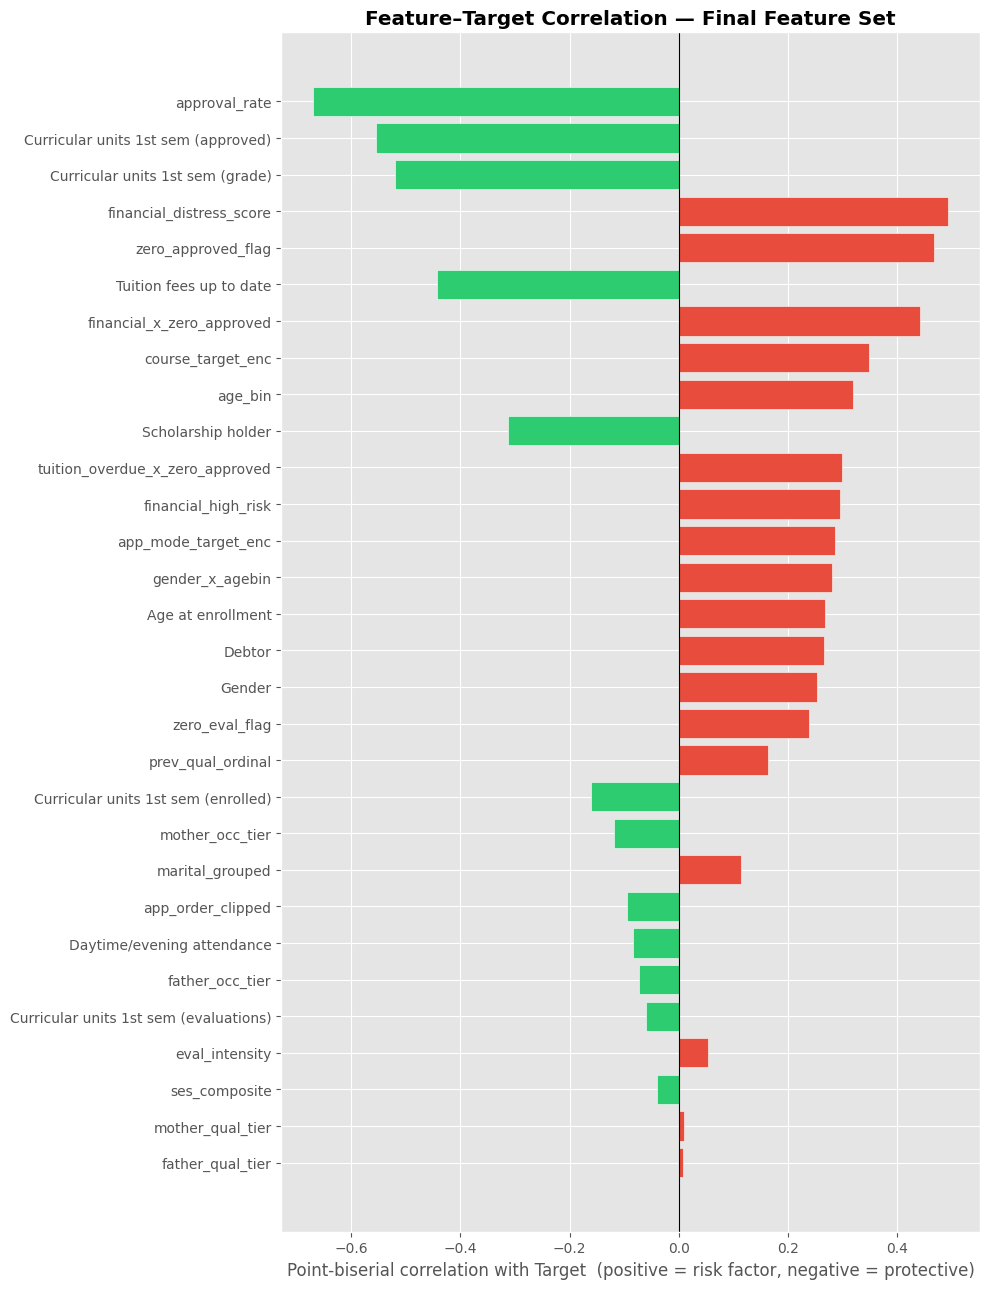

Top 15 features by absolute correlation with target:
                            feature    corr  p_value
                      approval_rate -0.6695   0.0000
Curricular units 1st sem (approved) -0.5542   0.0000
   Curricular units 1st sem (grade) -0.5188   0.0000
           financial_distress_score  0.4929   0.0000
                 zero_approved_flag  0.4660   0.0000
            Tuition fees up to date -0.4436   0.0000
          financial_x_zero_approved  0.4407   0.0000
                  course_target_enc  0.3482   0.0000
                            age_bin  0.3194   0.0000
                 Scholarship holder -0.3127   0.0000
    tuition_overdue_x_zero_approved  0.2981   0.0000
                financial_high_risk  0.2943   0.0000
                app_mode_target_enc  0.2848   0.0000
                    gender_x_agebin  0.2798   0.0000
                  Age at enrollment  0.2670   0.0000


In [40]:
# Point-biserial correlation of every feature with the target
pb_rows = []
for col in FEATURE_COLS:
    r, p = pointbiserialr(X[col], y)
    pb_rows.append({'feature': col, 'corr': r, 'p_value': p})

pb_df = (
    pd.DataFrame(pb_rows)
      .sort_values('corr', key=abs, ascending=False)
      .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 13))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in pb_df['corr']]
ax.barh(pb_df['feature'], pb_df['corr'], color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial correlation with Target  (positive = risk factor, negative = protective)')
ax.set_title('Feature–Target Correlation — Final Feature Set', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 15 features by absolute correlation with target:")
print(pb_df.head(15)[['feature', 'corr', 'p_value']].to_string(index=False))

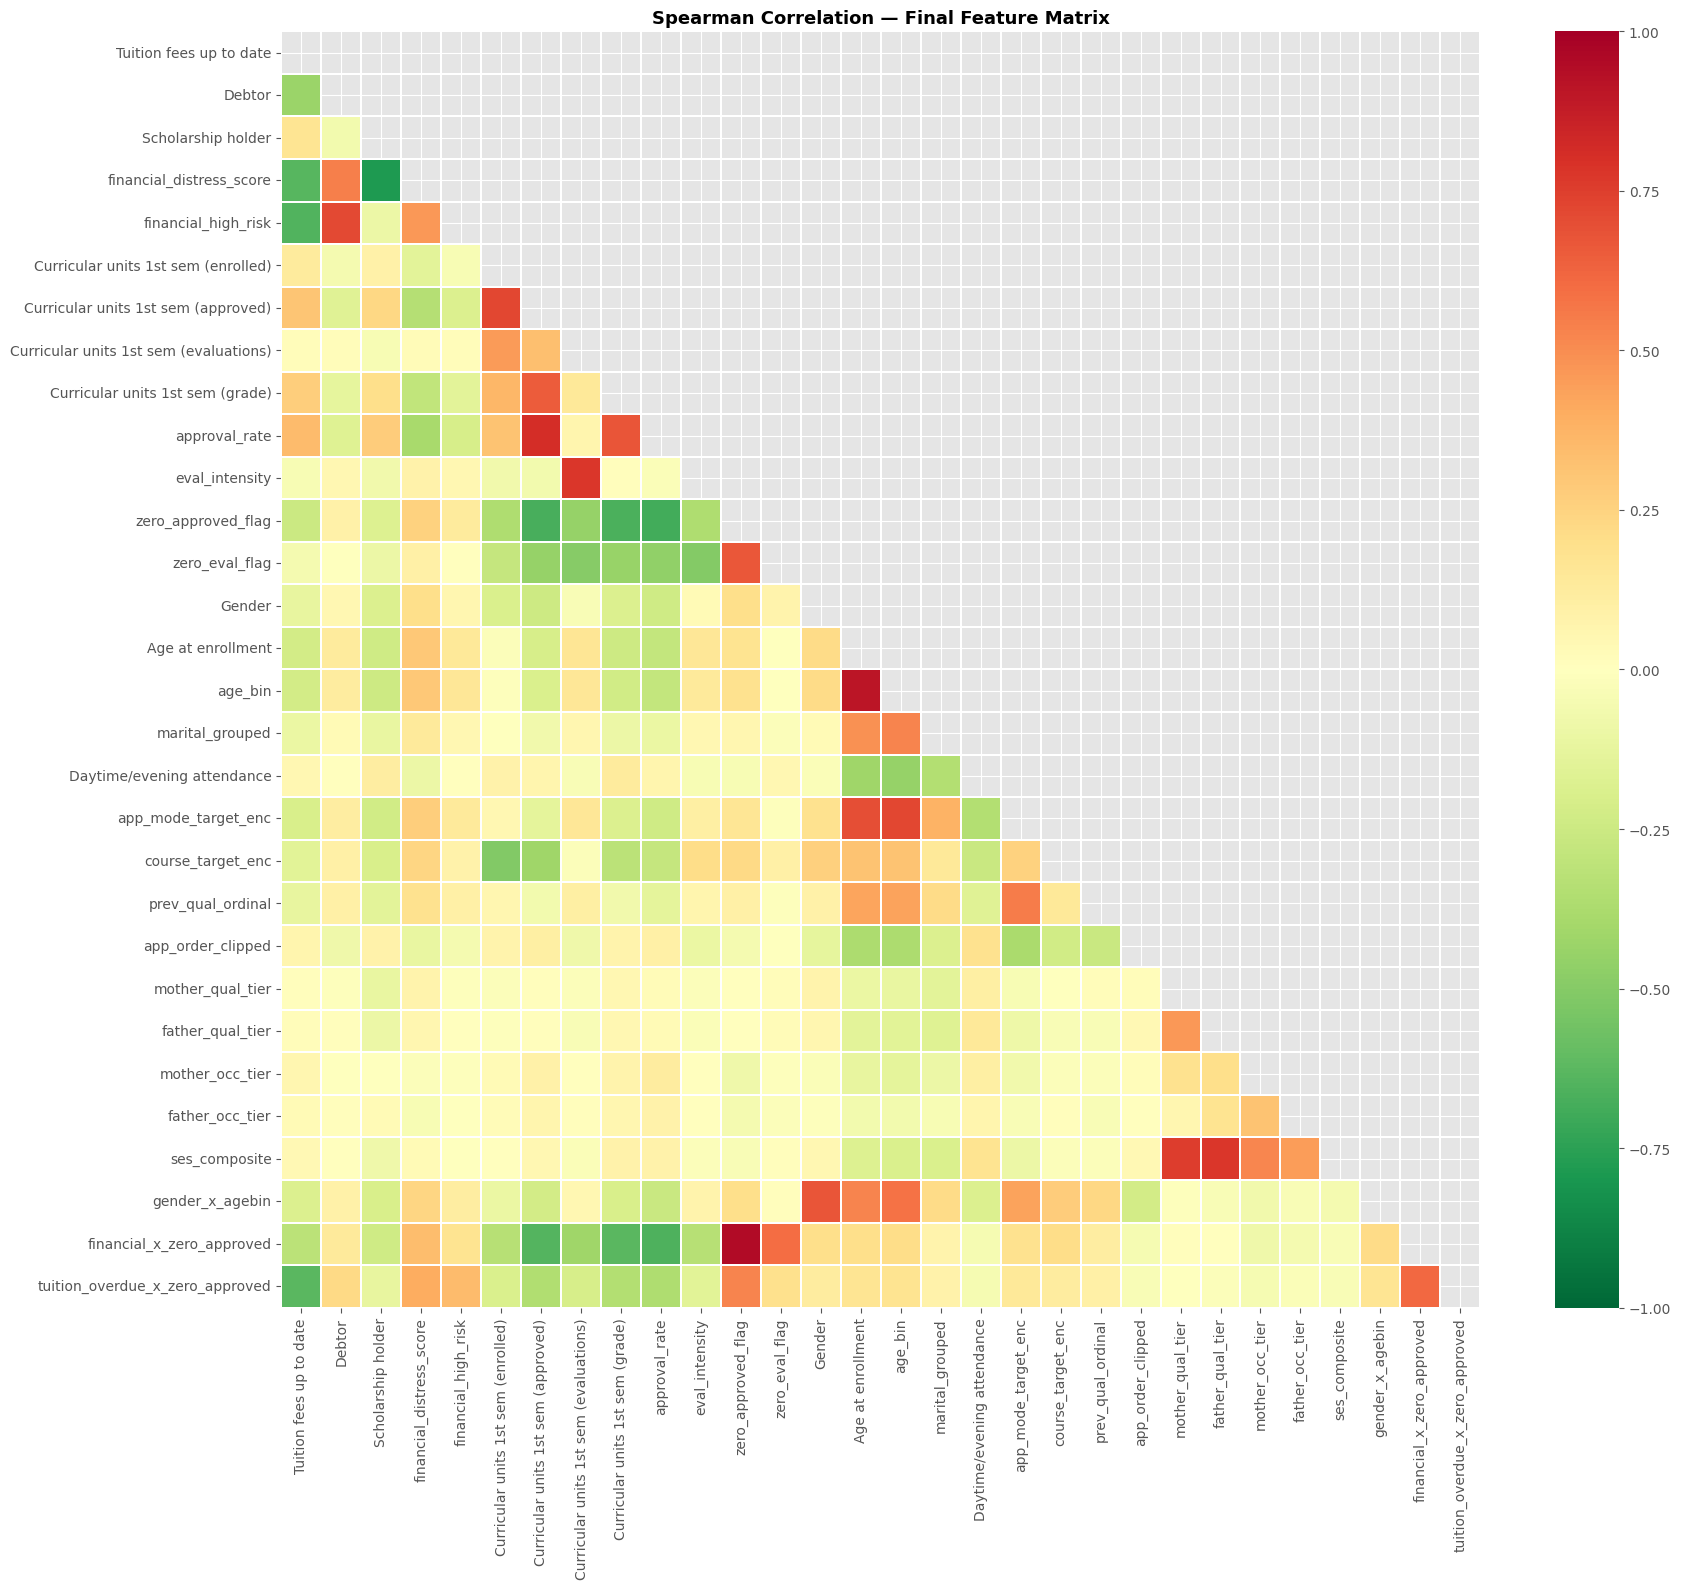

High-correlation pairs (|r| > 0.85) — review before modelling:
                Feature_A          Feature_B  abs_r
financial_x_zero_approved zero_approved_flag 0.9505
                  age_bin  Age at enrollment 0.9093


In [41]:
# Spearman correlation heatmap — check for residual high-correlation pairs
corr_matrix = X.corr(method='spearman')

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
    linewidths=0.2, ax=ax
)
ax.set_title('Spearman Correlation — Final Feature Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag pairs with |r| > 0.85
high_corr = (
    corr_matrix.abs()
               .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
               .stack()
               .reset_index()
               .rename(columns={'level_0': 'Feature_A', 'level_1': 'Feature_B', 0: 'abs_r'})
               .query('abs_r > 0.85')
               .sort_values('abs_r', ascending=False)
)

if len(high_corr) > 0:
    print("High-correlation pairs (|r| > 0.85) — review before modelling:")
    print(high_corr.to_string(index=False))
else:
    print("No feature pairs exceed |r| = 0.85  ✓")

The correlation chart confirms the EDA hierarchy of predictive signal. Academic features 
dominate the protective end — approval_rate (-0.67), approved units (-0.55), and grade 
(-0.52) are the three strongest individual features, all negatively correlated with dropout 
as expected. Financial features dominate the risk end — financial_distress_score (0.49), 
zero_approved_flag (0.47), and financial_x_zero_approved (0.44) are the strongest positive 
predictors. Tuition fees up to date (-0.44) and Scholarship holder (-0.31) appear as strong 
protective factors on the green side. The interaction and enrollment features sit in the 
mid-range, confirming they add signal beyond the raw variables without dominating the feature 
space. All 30 features have p-values of 0.000, confirming statistical significance throughout.


In [42]:
# Final summary statistics
display(X.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Tuition fees up to date,3618.0000,0.8670,0.3400,0.0000,1.0000,1.0000,1.0000,1.0000
Debtor,3618.0000,0.1140,0.3170,0.0000,0.0000,0.0000,0.0000,1.0000
Scholarship holder,3618.0000,0.2670,0.4420,0.0000,0.0000,0.0000,1.0000,1.0000
financial_distress_score,3618.0000,0.9800,0.7580,0.0000,1.0000,1.0000,1.0000,3.0000
financial_high_risk,3618.0000,0.0620,0.2410,0.0000,0.0000,0.0000,0.0000,1.0000
Curricular units 1st sem (enrolled),3618.0000,6.3390,2.5750,0.0000,5.0000,6.0000,7.0000,26.0000
Curricular units 1st sem (approved),3618.0000,4.7930,3.2400,0.0000,3.0000,5.0000,6.0000,26.0000
Curricular units 1st sem (evaluations),3618.0000,8.0780,4.2880,0.0000,6.0000,8.0000,10.0000,45.0000
Curricular units 1st sem (grade),3618.0000,10.5370,5.0550,0.0000,11.0000,12.3410,13.5000,18.8750
approval_rate,3618.0000,0.7000,0.3780,0.0000,0.5000,0.8570,1.0000,1.0000


The heatmap confirms that most feature pairs show low to moderate correlation, with the 
majority of cells appearing yellow or light — consistent with a well-engineered feature set. 
Two high-correlation pairs exceed the |r| = 0.85 threshold and warrant attention before 
modelling. The financial_x_zero_approved — zero_approved_flag pair at r=0.95 is expected: 
the interaction is non-zero only when zero_approved_flag = 1, making them structurally 
dependent. The age_bin — Age at enrollment pair at r=0.91 is also expected: the bin is 
derived directly from the continuous variable. Both pairs are intentional design choices 
where the raw and engineered versions are retained together to give tree-based models 
flexibility — Random Forest and Gradient Boosting handle correlated features without 
the same risk as linear models.

---
## 11. Save Outputs

In [43]:
out = Path('../datasets')
out.mkdir(exist_ok=True)

X.to_csv(out / 'X_train.csv', index=False)
y.to_csv(out / 'y_train.csv', index=False)

with open(out / 'feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Target encoding maps — saved for reference
# IMPORTANT: must be recomputed inside each CV fold in the modelling notebook
with open(out / 'target_enc_maps.json', 'w') as f:
    json.dump({
        'app_mode_group': {k: round(v, 6) for k, v in APP_MODE_ENC.items()},
        'course':         {str(k): round(v, 6) for k, v in COURSE_ENC.items()}
    }, f, indent=2)

print("Saved:")
print(f"  X_train.csv         {X.shape}")
print(f"  y_train.csv         {y.shape}  —  {y.mean():.1%} Dropout")
print(f"  feature_cols.json   {len(FEATURE_COLS)} features")
print(f"  target_enc_maps.json")

Saved:
  X_train.csv         (3618, 30)
  y_train.csv         (3618,)  —  39.2% Dropout
  feature_cols.json   30 features
  target_enc_maps.json


Four files are saved to the datasets directory. `X_train.csv` contains the 30-feature matrix 
for 3,618 students, and `y_train.csv` holds the binary target with 39.2% dropout. 
`feature_cols.json` records the exact ordered feature list to ensure reproducibility across 
any environment. `target_enc_maps.json` stores the application mode and course encoding maps 
computed on the full training set — these are saved for reference only and must be recomputed 
inside each cross-validation fold in the modelling notebook to prevent target leakage into 
the validation splits.

---
## 12. Conclusion

### What Was Done and Why

| Step | Action | Justification |
|---|---|---|
| Drop | 9 zero-signal variables removed | EDA Section 6 key findings table — no discriminative power confirmed |
| Academic | Approval rate + eval intensity ratios | Compresses enrolled-approved r=0.77 and enrolled-evaluations r=0.70 into normalised features |
| Academic | Zero-approved + zero-eval flags | Isolates structural zeros in grade; flags high-risk disengagement subgroups confirmed in EDA Section 4.5 |
| Financial | Distress score (0–3) + high-risk flag | EDA Sections 4.4 and 5.2 confirmed additive financial layers and the 6% to 95% dropout range across combinations |
| Demographic | Age binning (5 ordinal groups) | Non-linear risk confirmed in bivariate analysis; bins mirror EDA Section 5.2 interaction bins exactly |
| Demographic | Marital status — 3 categories | Codes 3, 4, 5, 6 have 2–75 observations — too sparse for reliable estimation |
| Enrollment | App mode grouped + target-encoded | 18 categories collapsed to 4 semantic pathway tiers; mature entry merged into special since age is already captured by `Age at enrollment` and `age_bin` |
| Enrollment | Course target-encoded | 17 categories with 17–89% dropout range; single ordinal signal avoids 17-column OHE |
| Enrollment | Prev qualification — 3-level ordinal | 83.1% secondary — only meaningful split is secondary vs post-secondary vs higher education |
| Enrollment | Application order clipped to [1, 5] | One code-0 student clipped; non-linear gradient preserved within retained range |
| Socioeconomic | 4 ordinal tiers + SES composite | Parental gradient confirmed in EDA Section 4.2; raw parental variables excluded in favour of tiers to avoid redundancy |
| Interactions | 3 interaction terms | All grounded in EDA Section 5.2 validated interactions |

### Design Principles

**EDA-driven.** Every decision is traceable to a specific finding in Notebook 1 or 2. Nothing was added speculatively.

**No redundancy.** Raw parental variables are excluded from the final feature set — their signal is fully captured by the ordinal tiers. Application mode and course raw columns are also excluded, replaced by their target-encoded versions.

**Leakage-controlled.** Target encoding maps are saved to `target_enc_maps.json` but must be recomputed inside each CV fold in the modelling notebook. Fitting them on the full training set here is for inspection only.

**Model-ready.** No scaling applied. Random Forest and Gradient Boosting are scale-invariant. All 30 features are numeric and contain no nulls.